# ENSIA LIBRARY BOOK RECOMMANDATIONS SYSTEM: PROBLEM

Ensia is a new school with a newly established library that plays a crucial role in supporting students throughout their five years of study. The library offers a vast collection of books across various fields to help students enrich their knowledge and support their academic projects. However, with such a large selection of books, it can be difficult for both the library and the students to determine which books are most relevant. The library struggles to identify which books to acquire based on demand, while students often find it challenging to choose the right book from the extensive collection. Our project seeks to simplify this process for both parties by applying data mining algorithms. These algorithms will help the library make informed decisions about which books to acquire based on demand trends and recommend the most relevant books to students based on their individual needs.


**DATASET**

The data files were obtained from the school’s library, there are three data files in total, each containing different useful information.

***1. Library Catalogue*:**


A data set with 623 rows, containing detailed information about the books available at the school’s library.

* **ISBN, ISSN**: 13/9 - digit numbers that uniquely identify books and book-like products published internationally.
* **Titre**: The title of the book, indicating its primary identifier for readers.
* **Auteur**: The name(s) of the individual(s) responsible for the creation of the book. 
* **Cote**: A unique combination of symbols used to identify the specific location of a book on the library shelves..
* **Nbr. Exp**: Represents the total number of copies of the same book available in the library’s inventory.

***2. Books Borrowed*:**

A dataset with 429 rows, containing detailed information about books borrowed from the library.
* **Numéro**: A unique identifier assigned to each book in the library.
* **Cote**:  represents the library's classification system used to organize and locate books on the shelves. It is a unique identifier composed of alphanumeric codes that typically include:
  * **Classification** **Number**: A numeric or symbolic representation indicating the subject or category of the book (e.g., 510 for mathematics, 518 for algorithms).
  * **Author's Initials or Code**: Letters that often represent the author's last name or an abbreviation for easier identification (e.g., MON for Monique, BAL for Balaguer).
  * **Edition or Volume Information (optional)**: Additional identifiers may include volume numbers or specific editions (e.g., "/1" for the first volume).AKA:refers to a single book that is part of a larger series or multi-part work
* **Titre**: The title of the book, serving as the primary identifier for readers.
* **Type de document**: Specifies the type of document (e.g., Livre for books).
* **N° lecteur**: A unique number assigned to the borrower of the book.
* **Nom**: The last name of the borrower.
* **Prénom**: The first name of the borrower.
* **Catégorie**: The category of the borrower, such as their academic year or role (e.g., 1ère Année, Enseignant).
* **Date prêt**: The date on which the book was borrowed.
* **Date retour**: The due date for returning the borrowed book.
* **Date réservation**: The reservation date, if applicable.

***3. Library inventory*:**

A tabular dataset composed of 4255 rows, used to manage and track the acquisition, classification, and status of books or other library materials. With each column representing a specific attribute of the item.

* **Inventory Number (N° inventaire)**: Represents the unique inventory number assigned to each book in the library.
* **Date of Receipt (Date de réception)**: The date the book was received by the library.
* **Title (Titre)**: The title of the book.
* **Author (Auteur)**: The author or authors of the book.
* **Editor (Editeur)**: The publisher responsible for the book's publication.
* **Edition Date (Date d'édition)**: The year the book was published.
* **Edition Location (Lieu d'édition)**: The place (city or country) where the book was published.
* **Edition (Edition)**: The edition of the book (e.g., 1st edition, 2nd edition).

* **Mode of Acquisition (Mode d'acquisition)**: How the item was acquired and the  possible values are:
  * ***Passif (Liability)***: books acquired through liability, meaning that the acquisition was financed by borrowing or taking on debt.
  * ***Achat (Purchase)***: through a direct purchase, meaning the acquisition was made with money or other exchange methods (like trade).
  * ***Don (Donation)***:  received as a gift or donation, meaning no monetary exchange was made in the acquisition process.
  
* **Status (Statut)**: The current status or condition of the book, its possible values are:
  * ***Prêt externe (External Loan)***: the book can be borrowed and taken outside the library premises for a specified period of time.
  * ***Consultation sur place (On-Site Consultation)***: the book is available for use or consultation only within the premises. It is not allowed to be taken outside the library.
  * ***Perdu (Lost)***: the book has been reported as lost and is no longer available in the inventory.
  
* **Supplier (Fournisseur)**: The supplier or source from which the item was acquired. From OPU(Office des Publications Universitaires) or Planete livres diffusion, or Ediscience diffusion.

* **Purchase Order Number (N° achat)**:The purchase order number or reference number for the acquisition.

* **Price (Prix)**:The price paid for the item.

* **Call Number (Cote)**: The call number, a classification or cataloging reference used in libraries to identify and locate items. The notations follow a pattern similar to library classification systems (like Dewey Decimal)

  * ***First Numeric Part (e.g., 519.85)***: Represents the subject area (mathematics in this case) and the book's specific focus.
  * Author or Title Abbreviation (e.g., MIN, FOA, PIS):Represents the author's surname or the title abbreviation. For example, MIN could refer to an author named "Minoux," FOA to "Foata," and PIS to "Piskounov."
  
* **Additional Identifiers or Volume Numbers (e.g., /1, /4/2)**:  Indicates specific volumes, editions, or other relevant details for multi-part books. These identifiers are separated by slashes. For example, 515.33/PIS/1 refers to a book on differential and integral calculus (515.33), authored by "Piskounov" (PIS), and it is likely the first volume of a series. 510.76.DUP/1 refers to another book, and "DUP" indicates the author or title, while "/1" could indicate the first part of the series.

* **Location (Localisation)**: The location within the library or organization where the item is stored (e.g.,"ENSIA" and "Transféré l'ENSIA"). 
  * ***ENSIA***: This likely refers to the location where the item is stored or used. 
  * ***Transféré l'ENSIA***: This means that the item has been transferred to ENSIA, indicating that the item was moved from another location or entity to ENSIA.

* **Observation (Observation)**: Additional notes or remarks about the item.
* **Titre remplacé**: The original title has been replaced.
* **B. Dep - informatique**: suggests that the book is placed under or associated with the Information Technology department of the institution.
*** T.remplacé**: A volume or edition has been replaced.
* **Photo copie**: The item is a photocopy.


# Solution Overview:
To recommend books based on students, we will apply:
* classification: to classify the books based on the course they serve.
* Clustering: based on the classification results, we will cluster books based on their popularity and then recommend the modst popular ones.
* Association rules: we will use association rule mining to get more suggestions based on the popular books.

# Data cleaning

In [1]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from mlxtend.frequent_patterns import apriori
from tabulate import tabulate

# INVENTORY CLEANING

We first load the inventory file into a dataframe, remove the .0 from the years. 

In [2]:
data = pd.read_csv('data/LIBRARY INVENTORY.csv', header='infer')
data.columns = ['N° Inventaire', 'Date de réception', 'Titre', 'Auteur', 'Editeur', 'Date d\'édition', 
                'Lieu d\'édition', 'Edition', 'Mode d\'acquisition', 'Statut', 'Fournisseur', 'N° achat', 
                'Prix', 'Cote', 'Localisation', 'Observation']
data['Date d\'édition'] = data['Date d\'édition'].astype(str).str.replace(r'\.0$', '', regex=True)
data['Date de réception'] = data['Date de réception'].astype(str)

print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))
data.head()

Number of instances = 4255
Number of attributes = 16


,N° Inventaire,Date de réception,Titre,Auteur,Editeur,Date d'édition,Lieu d'édition,Edition,Mode d'acquisition,Statut,Fournisseur,N° achat,Prix,Cote,Localisation,Observation
0,62504,nan,Programmation mathématique : théorie et algori...,"Minoux, Michel",Lavoisier,2008,Paris,2e éd.,Passif,NaN,NaN,NaN,NaN,519.85 MIN,ENSIA,Titre remplacé
1,111442,nan,"Calcul des probabilités : cours, exercices et ...","Foata, Dominique",Dunod,2012,Paris,3e éd.,Passif,Prêt externe,NaN,NaN,NaN,519.2/FOA,Transféré l'ENSIA,NaN
2,1,19/12/2021,Calcul DIfferentiel et Integral Tome 01,"Piskounov,N",Office des Publications Universitaires,2006,algerie,NaN,Achat,Prêt externe,opu,1-nov.-21,"889,91",515.33/PIS/1,ENSIA,NaN
3,10,1/11/2021,Calcul Differentiel Et Integral Tome 2,"Piskounov,N",OPU,2016,Algerie,NaN,Achat,Prêt externe,NaN,NaN,NaN,515.33/PIS/4/2,ENSIA,NaN
4,100,nan,Introduction à l'analyse mathématique : nombre...,Abdelkader Khelladi,OPU,2018,Alger,3 ED.,Achat,Prêt externe,NaN,NaN,NaN,515/KHE/5,ENSIA,NaN


In [3]:
# Count how many rows contain '????' or blank (empty string) in all columns
for col in data.columns:
    data[col] = data[col].astype(str)
    count_invalid = data[col].str.contains(r'\?{4}', na=False).sum() + (data[col].str.strip() == '').sum()
    print(f"Rows in '{col}' containing '????' or blank: {count_invalid}")



Rows in 'N° Inventaire' containing '????' or blank: 0
Rows in 'Date de réception' containing '????' or blank: 0
Rows in 'Titre' containing '????' or blank: 79
Rows in 'Auteur' containing '????' or blank: 74
Rows in 'Editeur' containing '????' or blank: 29
Rows in 'Date d'édition' containing '????' or blank: 0
Rows in 'Lieu d'édition' containing '????' or blank: 34
Rows in 'Edition' containing '????' or blank: 1
Rows in 'Mode d'acquisition' containing '????' or blank: 0
Rows in 'Statut' containing '????' or blank: 0
Rows in 'Fournisseur' containing '????' or blank: 0
Rows in 'N° achat' containing '????' or blank: 0
Rows in 'Prix' containing '????' or blank: 0
Rows in 'Cote' containing '????' or blank: 24
Rows in 'Localisation' containing '????' or blank: 0
Rows in 'Observation' containing '????' or blank: 0


#### **Dropping columns which do not contribute to the recommendation system's goals**
* *'Date de réception'*: Irrelevant for recommendation logic
* *'Mode d'acquisition'*: Acquisition type doesn't impact recommendations
* *'Lieu d'edition'*: doesn't impact recommendations
* *'Fournisseur'*: Supplier data is not relevant for users
* *'Localisation'*: Not relevant for recommendations
* *'N° achat'*: Purchase order information is irrelevant
* *'Prix'*: Pricing isn't a factor in library/student recommendations
* *'Observation'*: Contains mostly NaN values or unstructured remarks

In [4]:
columns_to_drop = [
    'Date de réception', 'Mode d\'acquisition', 'Lieu d\'édition','Localisation' ,
    'Fournisseur', 'N° achat', 'Prix', 'Observation'
]
newdata = data.drop(columns=columns_to_drop)

print("Columns retained for the recommendation system:")
newdata.head()

Columns retained for the recommendation system:


,N° Inventaire,Titre,Auteur,Editeur,Date d'édition,Edition,Statut,Cote
0,62504,Programmation mathématique : théorie et algori...,"Minoux, Michel",Lavoisier,2008,2e éd.,nan,519.85 MIN
1,111442,"Calcul des probabilités : cours, exercices et ...","Foata, Dominique",Dunod,2012,3e éd.,Prêt externe,519.2/FOA
2,1,Calcul DIfferentiel et Integral Tome 01,"Piskounov,N",Office des Publications Universitaires,2006,nan,Prêt externe,515.33/PIS/1
3,10,Calcul Differentiel Et Integral Tome 2,"Piskounov,N",OPU,2016,nan,Prêt externe,515.33/PIS/4/2
4,100,Introduction à l'analyse mathématique : nombre...,Abdelkader Khelladi,OPU,2018,3 ED.,Prêt externe,515/KHE/5


Apply lowercase to all string columns in the dataset except column names

In [5]:
newdata = newdata.apply(lambda x: x.str.lower() if x.dtype == "object" else x)
newdata.head()

,N° Inventaire,Titre,Auteur,Editeur,Date d'édition,Edition,Statut,Cote
0,62504,programmation mathématique : théorie et algori...,"minoux, michel",lavoisier,2008,2e éd.,nan,519.85 min
1,111442,"calcul des probabilités : cours, exercices et ...","foata, dominique",dunod,2012,3e éd.,prêt externe,519.2/foa
2,1,calcul differentiel et integral tome 01,"piskounov,n",office des publications universitaires,2006,nan,prêt externe,515.33/pis/1
3,10,calcul differentiel et integral tome 2,"piskounov,n",opu,2016,nan,prêt externe,515.33/pis/4/2
4,100,introduction à l'analyse mathématique : nombre...,abdelkader khelladi,opu,2018,3 ed.,prêt externe,515/khe/5


**We standardize the edition format as there were many different ones!**

In [6]:
pd.set_option('display.max_rows', None)

def standardize_edition(edition):
    edition = re.sub(r'[\W_]+', ' ', edition)
    edition = edition.replace("réimpr", "").strip()
    match = re.match(r'(\d+)(.*)', edition)
    if match:
        number = match.group(1)
        return f"{number} ed"
    else:
        return edition

newdata['Edition'] = newdata['Edition'].apply(standardize_edition)

print("Updated 'Edition' column with standardized notation:")
print(newdata[['Edition']].head(10))


Updated 'Edition' column with standardized notation:
  Edition
0    2 ed
1    3 ed
2     nan
3     nan
4    3 ed
5     nan
6    3 ed
7    3 ed
8    3 ed
9    3 ed


 **Find rows where 'Editeur' contains numerical values**

In [7]:
def has_numerical_values(editor):
    return bool(re.search(r'\d+', str(editor)))

rows_with_numbers = newdata[newdata['Editeur'].apply(has_numerical_values)]

There are none so
**We check the validity of the year if it is greater than 2024/2025 we remove it**

In [8]:
current_year = datetime.now().year

def validate_date(date):
    try:
        year = str(date).strip()
        
        if len(year) == 4 and year.isdigit():
            year_int = int(year)
            if 1000 <= year_int <= current_year:
                return year_int
            else:
                return np.nan
        else:
            return np.nan
    except ValueError:
        return np.nan

newdata['Date d\'édition'] = newdata['Date d\'édition'].astype(str).str.replace(r'\.0$', '', regex=True)
newdata['Date d\'édition'] = newdata['Date d\'édition'].apply(validate_date)



In [9]:
newdata['Date d\'édition'] = newdata['Date d\'édition'].astype(str).str.replace(r'\.0$', '', regex=True)
newdata.head()

,N° Inventaire,Titre,Auteur,Editeur,Date d'édition,Edition,Statut,Cote
0,62504,programmation mathématique : théorie et algori...,"minoux, michel",lavoisier,2008,2 ed,nan,519.85 min
1,111442,"calcul des probabilités : cours, exercices et ...","foata, dominique",dunod,2012,3 ed,prêt externe,519.2/foa
2,1,calcul differentiel et integral tome 01,"piskounov,n",office des publications universitaires,2006,nan,prêt externe,515.33/pis/1
3,10,calcul differentiel et integral tome 2,"piskounov,n",opu,2016,nan,prêt externe,515.33/pis/4/2
4,100,introduction à l'analyse mathématique : nombre...,abdelkader khelladi,opu,2018,3 ed,prêt externe,515/khe/5


In [10]:
# Convert 'N° Inventaire' to numeric, forcing errors to NaN
data['N° Inventaire'] = pd.to_numeric(data['N° Inventaire'], errors='coerce')
data = data[data['N° Inventaire'] >= 0]
invalid_values = data[data['N° Inventaire'].isna()]

if invalid_values.empty:
    print("All values in 'N° Inventaire' are valid.")
else:
    print("Invalid values in 'N° Inventaire':")
    print(invalid_values[['N° Inventaire']])


All values in 'N° Inventaire' are valid.


 **Find rows where 'Titre' contains '????'**  w drop those that are not in the catalogue and there are no ways of recovering them.

In [11]:
pd.set_option('display.max_rows', None)
invalid_title_rows = data[data['Titre'].str.contains(r'\?{4}', na=False)]
invalid_title_rows = invalid_title_rows[['Titre', 'Cote']]
invalid_title_rows.head(10)


,Titre,Cote
127,??????? ????? ?????,512.???
162,???? ?? ?????????? ???????? ??????,514.???
260,??????? ?? ????? ?????,512 .???
262,??????? ?? ????? ?????,512 .???
263,??????? ?? ????? ?????,512 .???
264,????? ????????? ???1 : ????? ?????,512 ???
265,????? ????????? ???1 : ????? ?????,512 ???
266,????? ????????? ???1 : ????? ?????,512 ???
267,????? ? ???????,512.????
268,????? ? ???????,512.????


Drop books that are lost/perdu as there is no need to suggest them.

In [12]:
print(newdata.shape[0])
rows_drop_inv = (newdata['Statut'] == 'perdu')

newdata = newdata.drop(index=newdata[rows_drop_inv].index)
print(newdata.shape[0])

4255
4254


Looking for books with ???? title and missing cote (no way of recovering them using the catalogue).

In [13]:
from tabulate import tabulate

pd.set_option('display.max_rows', None)

newdata['Cote'] = newdata['Cote'].str.strip()
newdata['Cote'] = newdata['Cote'].replace(['nan', 'NaN', ''], pd.NA)

invalid_rows = newdata[
    newdata['Titre'].str.contains(r'\?+', na=False) & 
    (newdata['Cote'].isna())
]

print("\nRows where 'Titre' contains question marks AND 'Cote' is missing:")
#print(tabulate(invalid_rows, headers='keys', tablefmt='grid'))

invalid_rows.head(5)


Rows where 'Titre' contains question marks AND 'Cote' is missing:


,N° Inventaire,Titre,Auteur,Editeur,Date d'édition,Edition,Statut,Cote
1062,1980,????? ??????? ?? ??????????? : ?????? ????? ??...,???? ?????,opu,2017,nan,prêt externe,<NA>
1506,238,????? ???????? ??? ???????? ??????? ? ????????...,nan,nan,nan,nan,prêt externe,<NA>
1517,239,?????? ??? ????? ??????? ????????,nan,nan,nan,nan,consultation sur place,<NA>
1540,241,???????? ?????? ?????? ???????? ?????????? ???...,nan,nan,nan,nan,consultation sur place,<NA>
1551,242,??????? ?? ???????? ?????? ????????,nan,nan,nan,nan,consultation sur place,<NA>


**we drop those rows**

In [14]:
newdata_cleaned = newdata.drop(invalid_rows.index)

print("\nCleaned DataFrame (after dropping invalid rows):")
newdata_cleaned.head(5)


Cleaned DataFrame (after dropping invalid rows):


,N° Inventaire,Titre,Auteur,Editeur,Date d'édition,Edition,Statut,Cote
0,62504,programmation mathématique : théorie et algori...,"minoux, michel",lavoisier,2008,2 ed,nan,519.85 min
1,111442,"calcul des probabilités : cours, exercices et ...","foata, dominique",dunod,2012,3 ed,prêt externe,519.2/foa
2,1,calcul differentiel et integral tome 01,"piskounov,n",office des publications universitaires,2006,nan,prêt externe,515.33/pis/1
3,10,calcul differentiel et integral tome 2,"piskounov,n",opu,2016,nan,prêt externe,515.33/pis/4/2
4,100,introduction à l'analyse mathématique : nombre...,abdelkader khelladi,opu,2018,3 ed,prêt externe,515/khe/5


# CATALOGUE CLEANING

**We remove rows that contain no ISBN nor title nor Cote (no way of identifying them and finding them in the other available files).**

In [15]:
libraryCatalogue = pd.read_csv('data/library_catalogue.csv')
print("Number of rows in the catalogue before dropping the unncessary rows:",libraryCatalogue.shape[0])
rows_to_drop = (
    (libraryCatalogue["ISBN, ISSN"].isnull() &
    libraryCatalogue['Titre'].str.contains(r'\?+', na=False) &
    (libraryCatalogue['Cote'].str.contains(r'\?+', na=False) | libraryCatalogue['Cote'].isnull()))
)

libraryCatalogue = libraryCatalogue.drop(index=libraryCatalogue[rows_to_drop].index)

filtered_rows = libraryCatalogue[libraryCatalogue['Titre'].str.contains(r'\?\?', na=False)]

total_matching_rows = filtered_rows.shape[0]
libraryCatalogue = libraryCatalogue.drop(index=filtered_rows.index)
print("Number of rows in the catalogue after dropping the unncessary rows:",libraryCatalogue.shape[0])

Number of rows in the catalogue before dropping the unncessary rows: 620
Number of rows in the catalogue after dropping the unncessary rows: 583


 # BORROWED BOOKS FILE CLEANING

**we load the borrowed books file into a dataframe to use it**

In [16]:
borrowings = pd.read_csv('data/library data .xlsx - DocEmpruntes.csv', header=6)
borrowings.head()

,Numéro,Cote,Titre,Type de document,N° lecteur,Nom,Prénom,Catégorie,Date prêt,Date retour,Date réservation
0,1000,515 MON,Exercices corrigés d'analyse : 1ère année LMD,Livre,5817912,MAMECHE,FERIEL,1 ére ANNEE,10/15/2024,10/30/2024,NaN
1,1005,510.BAL/1,Exercices d'algèbre et d'analyse : 154 exercic...,Livre,5754033,fourali,malak,1 ére ANNEE,10/17/2024,11/3/2024,NaN
2,1006,510.BAL/2,Exercices d'algèbre et d'analyse : 154 exercic...,Livre,5113394,SEHALI,MAYA,1 ére ANNEE,10/1/2024,10/16/2024,NaN
3,1007,510.BAL/3,Exercices d'algèbre et d'analyse : 154 exercic...,Livre,6092419,kheddaoui,thiziri,1 ére ANNEE,10/15/2024,10/30/2024,NaN
4,1009,518.107.BAY/1,Exercices et problèmes d'algorithmique : 144 é...,Livre,8354464,GACEB,RIHAM BAHIA,3 ème ANNEE,10/17/2023,10/24/2023,NaN



**we drop the unnecessary columns that won't help in our analysis**

In [17]:
borrowings = borrowings.drop(['Type de document'], axis=1)
borrowings.head()

,Numéro,Cote,Titre,N° lecteur,Nom,Prénom,Catégorie,Date prêt,Date retour,Date réservation
0,1000,515 MON,Exercices corrigés d'analyse : 1ère année LMD,5817912,MAMECHE,FERIEL,1 ére ANNEE,10/15/2024,10/30/2024,NaN
1,1005,510.BAL/1,Exercices d'algèbre et d'analyse : 154 exercic...,5754033,fourali,malak,1 ére ANNEE,10/17/2024,11/3/2024,NaN
2,1006,510.BAL/2,Exercices d'algèbre et d'analyse : 154 exercic...,5113394,SEHALI,MAYA,1 ére ANNEE,10/1/2024,10/16/2024,NaN
3,1007,510.BAL/3,Exercices d'algèbre et d'analyse : 154 exercic...,6092419,kheddaoui,thiziri,1 ére ANNEE,10/15/2024,10/30/2024,NaN
4,1009,518.107.BAY/1,Exercices et problèmes d'algorithmique : 144 é...,8354464,GACEB,RIHAM BAHIA,3 ème ANNEE,10/17/2023,10/24/2023,NaN


**We check for duplicates, if any**

In [18]:
duplicates = borrowings[borrowings.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [Numéro, Cote, Titre, N° lecteur, Nom, Prénom, Catégorie, Date prêt, Date retour, Date réservation]
Index: []


In [19]:
borrowings['Nom'] = borrowings['Nom'].str.lower()
borrowings['Prénom'] = borrowings['Prénom'].str.lower()
borrowings['Catégorie'] = borrowings['Catégorie'].str.lower()
borrowings['Titre'] = borrowings['Titre'].str.lower()

borrowings.head()

,Numéro,Cote,Titre,N° lecteur,Nom,Prénom,Catégorie,Date prêt,Date retour,Date réservation
0,1000,515 MON,exercices corrigés d'analyse : 1ère année lmd,5817912,mameche,feriel,1 ére annee,10/15/2024,10/30/2024,NaN
1,1005,510.BAL/1,exercices d'algèbre et d'analyse : 154 exercic...,5754033,fourali,malak,1 ére annee,10/17/2024,11/3/2024,NaN
2,1006,510.BAL/2,exercices d'algèbre et d'analyse : 154 exercic...,5113394,sehali,maya,1 ére annee,10/1/2024,10/16/2024,NaN
3,1007,510.BAL/3,exercices d'algèbre et d'analyse : 154 exercic...,6092419,kheddaoui,thiziri,1 ére annee,10/15/2024,10/30/2024,NaN
4,1009,518.107.BAY/1,exercices et problèmes d'algorithmique : 144 é...,8354464,gaceb,riham bahia,3 ème annee,10/17/2023,10/24/2023,NaN


In [20]:
unique_values = borrowings['Catégorie'].unique()
print(unique_values)

['1 ére annee' '3 ème annee' 'enseignant' '2 éme annee' '4 éme annee'
 'employé']


**We check for missing values in the entire data file**

In [21]:
empty_rows = borrowings[borrowings.isna().any(axis=1)]
empty_rows.head()
print(borrowings.isna().sum())


Numéro                0
Cote                 14
Titre                 0
N° lecteur            0
Nom                   0
Prénom                0
Catégorie             0
Date prêt             0
Date retour           0
Date réservation    414
dtype: int64


**We cast the dates from object to date time**

In [22]:
print(borrowings.dtypes)

Numéro               int64
Cote                object
Titre               object
N° lecteur          object
Nom                 object
Prénom              object
Catégorie           object
Date prêt           object
Date retour         object
Date réservation    object
dtype: object


In [23]:
borrowings['Date prêt'] = pd.to_datetime(borrowings['Date prêt'])
borrowings['Date retour'] = pd.to_datetime(borrowings['Date retour'])
borrowings['Date réservation'] = pd.to_datetime(borrowings['Date réservation'])
print(borrowings.dtypes)

Numéro                       int64
Cote                        object
Titre                       object
N° lecteur                  object
Nom                         object
Prénom                      object
Catégorie                   object
Date prêt           datetime64[ns]
Date retour         datetime64[ns]
Date réservation    datetime64[ns]
dtype: object


### Categorical columns visualization: Frequency of 'Catégorie' to get clear insights about the borrowers we are dealing with mainly

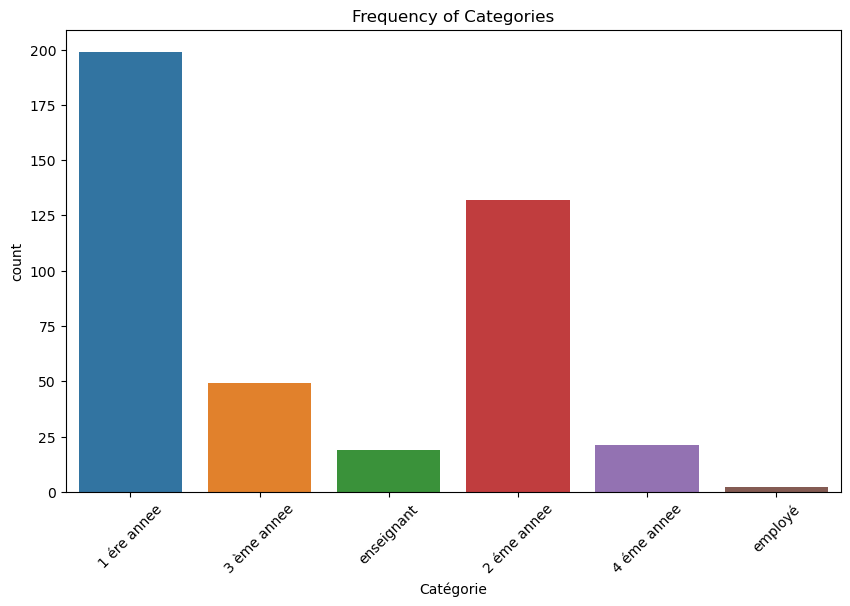

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=borrowings, x='Catégorie')
plt.title('Frequency of Categories')
plt.xticks(rotation=45)
plt.show()


#### perform a check for invalid dates (return date before borrowing date), if any.

In [25]:
invalid_dates = borrowings[borrowings['Date prêt'] > borrowings['Date retour']]
if not invalid_dates.empty:
    print("Rows where 'Date prêt' is after 'Date retour':")
    print(invalid_dates)
else:
    print("No rows found where 'Date prêt' is after 'Date retour'.")

No rows found where 'Date prêt' is after 'Date retour'.


# SPLITTING DATA INTO TRAIN/TEST SETS

In [26]:
data = libraryCatalogue

catalogue_train_data, catalogue_test_data = train_test_split(data, test_size=0.3, random_state=42)

print(f"Training Data: {len(catalogue_train_data)} rows")
print(f"Testing Data: {len(catalogue_test_data)} rows")


Training Data: 408 rows
Testing Data: 175 rows


# TRAINING THE MODEL

**In this section we are going to use our train data to train our model on classification then use the classification data to perform clustering and then the association rule mining to get our model's performance insights.**

we define categories of the courses that are taught here at ENSIA. each with the most possible repetitive keywords that could be found in the books titles.

In [27]:
categories = {
    "Foundational Mathematics": [
        "calculabilité", "calcul","Mathematique",
        "mathematiques","algébrique",
        "algébre","l'algèbre","Algèbre",
        "algebre","algébriques",
        "mathematics", "maths","arithmetics", "geometry", 
        "trigonometry", "mathématiques", "arithmétique", "géométrie", "trigonométrie","d'algèbre"
    ],
  
    "logic":[
        "logique","  logique mathématique","logic"
    ],
    "Digital Systems": [
        "digital systems", "logic design", "microprocessors", 
        "systèmes numériques", "conception logique", "microprocesseurs"
    ],
    "Information Technology Essentials": [
        "information technology", "IT essentials", "networking basics", 
        "technologies de l'information", "bases des réseaux", "TI essentielles", "internet"
    ],
    "English": [
        "english", "anglais", "language", "langue","writing","speaking","listening"
    ],
    "Critical Thinking": [
        "critical thinking", "problem solving", "pensée critique", "résolution de problèmes"
    ],
    "OOP": [
        "object-oriented programming", "oop", "programming paradigms", 
        "programmation orientée objet", "poo", "paradigmes de programmation"
    ],
    "Linux": [
        "linux", "shell scripting", "system administration", 
        "administration système", "scripting shell", "unix"
    ],
    "Linear Algebra": [
        "linear algebra", "vectors", "matrices", "algèbre linéaire", "vecteurs", "matrices"
    ],
    "Mathematical Analysis": [
        "intégrale","differentiel","d’analyse",
        "fonction","integral",
        "equations differentielles","développements limités",
        "mathematical analysis", "analysis", "derivatives", "integrals", 
        "analyse mathématique", "dérivées", "intégrales","analyse"
    ],
    "Statistics": [
        "statistique",
        "statistics", "data analysis", "statistical methods", 
        "statistiques", "analyse de données", "méthodes statistiques"
    ],
    "Databases": [
        "databases", "SQL", "database design", "bases de données", "conception de bases", "database"
    ],
    "Probability": [
        "probabilites", "probability", "random variables", "probabilités", "variables aléatoires","probabilities", "Probabilité"
    ],
    "Web Development": [
        "web development", "HTML", "CSS", "JavaScript", "développement web", "html", "css", "js","web"
    ],
    "Business": [
        "business", "management", "finance", "entreprise", "gestion", "finances"
    ],
    "Theory of Computing": [
        "theory of computing", "automata", "turing machines", 
        "théorie de l'informatique", "automates", "machines de turing"
    ],
    "Operating Systems": [
        "systémes d'exploitation","java",
        "systeme","réseaux",
        "systeme d'exploitation",
        "operating systems", "os", "processes", "filesystems", 
        "systèmes d'exploitation", "processus", "systèmes de fichiers"
    ],
    "Computer Architecture": [
        "architectures","structure des ordinateurs", "bit", "binaire", "RISC", "CISC","architecture",
        "computer architecture", "hardware design", "conception matérielle", "architecture des ordinateurs"
    ],
    "Artificial Intelligence": [
        "artificial inteligence ","python",
        "artificial intelligence", "ai ", "machine learning", "deep learning", 
        "intelligence artificielle", "apprentissage automatique", "deep learning"
    ],
    "Electronic Circuits Labs": [
        "circuits", "electronic circuits", "electrical circuits",
        "circuits électroniques", "circuits électriques","électroniques"
    ],
    "Data Mining": [
        "data mining", "knowledge discovery", "text mining", "Data",
        "fouille de données", "découverte de connaissances", "analyse textuelle"
    ],
    "Operation Research": [
        "operation research", "optimization", "linear programming", 
        "recherche opérationnelle", "optimisation", "programmation linéaire"
    ],
    "Stochastic Simulation": [
        "stochastic simulation", "random processes", "simulation stochastique", "processus aléatoires"
    ],
    "Software Engineering": [
        "modélisation","génie logiciel","agile",
        "software engineering", "design patterns", "testing", 
        "ingénierie logicielle", "modèles de conception", "tests"
    ],
    "Networks and Protocols": [
        "networks", "protocols", "TCP/IP", "wireless", 
        "réseaux", "protocoles", "tcp/ip", "sans fil"
    ],
    "Mobile Development": [
        "mobile development", "android", "flutter", 
        "développement mobile",
    ],
    "Entrepreneurship and Innovation": [
        "entrepreneurship", "startups", "innovation", "market",
        "entrepreneuriat", "start-ups", "innovation"
    ],
    "Machine Learning": [
        "machine learning", "machine","regression", "classification", "neural networks", 
        "apprentissage automatique", "régression", "réseaux neuronaux", "Reinforcement"
    ],
    "Numerical Methods and Optimization": [
        "numerical methods", "optimization", "finite differences", 
        "méthodes numériques", "optimisation", "différences finies"
    ],
    "Time Series": [
        "time series", "forecasting", "series temporelles", "prévision"
    ],
    "Computer and Network Security": [
        "security", "cryptography", "network security", 
        "sécurité", "cryptographie", "sécurité des réseaux"
    ],
    "Physics":[
        "physique","topographie",
    ],
      "Data Structures and Algorithms": [
          "algorithmique","programmation",
        "compilation","informatique",
        "c++",
        "algorithmique",
        "data structures", "algorithms", "sorting", "trees", "graphs", 
        "algorithmes", "structures de données", "tri", "arbres", "graphes"
    ],
    "Chimie": [
        "chimie", "chimie organique"
    ],
    "others":[
        "anatomie","marketing","chimie"
    ]
}

#### Here we train a Decision Tree Classifier to categorize book titles based on keyword matching with predefined categories. It then evaluates the model's performance, extracts decision rules, and saves the classification results to a CSV file.

The encode_keywords function converts book titles into a binary feature representation based on keyword matching with predefined categories.

* **Feature Encoding**:

It iterates over each book title and checks if keywords from each category appear in the title.
A binary feature vector is created, where each element represents whether at least one keyword from a given category is present in the title (True if present, False otherwise).
* **Category Inference**:

The function also determines the most relevant category for each title by counting keyword matches.
The category with the highest keyword count is assigned; if no keywords match, it is labeled as "Unknown".

The result of the classification is then stored in a csv file for later use.

In [28]:
catalogue_train_data["Titre"] = catalogue_train_data["Titre"].fillna("").astype(str)
catalogue_test_data["Titre"] = catalogue_test_data["Titre"].fillna("").astype(str)


def encode_keywords(titles, categories):
    encoded_data = []
    inferred_types = []  
    for title in titles:
        features = []
        best_match_count = 0
        best_match_category = None
       
        for category, keywords in categories.items():
            keyword_count = sum(1 for keyword in keywords if keyword.lower() in title.lower())
            features.append(keyword_count > 0)
            
            if keyword_count > best_match_count:
                best_match_count = keyword_count
                best_match_category = category
        inferred_types.append(best_match_category if best_match_category else "Unknown")
        encoded_data.append(features)
    
    return pd.DataFrame(encoded_data, columns=categories.keys()), inferred_types
               
X_train, y_train = encode_keywords(catalogue_train_data["Titre"], categories)
X_test, y_test = encode_keywords(catalogue_test_data["Titre"], categories)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_train)


print("\nDecision Tree Rules:")
tree_rules = export_text(clf, feature_names=X_train.columns.tolist() if isinstance(X_train, pd.DataFrame) else [X_train.name])
print(tree_rules)


train_labels = pd.DataFrame({
    "Title": catalogue_train_data["Titre"].reset_index(drop=True), 
    "True Labels": y_train,
    "Predicted Labels": y_pred
})


output_file = "classification_results.csv"
train_labels.to_csv(output_file, index=False)




Decision Tree Rules:
|--- Foundational Mathematics <= 0.50
|   |--- Mathematical Analysis <= 0.50
|   |   |--- Data Structures and Algorithms <= 0.50
|   |   |   |--- Operating Systems <= 0.50
|   |   |   |   |--- English <= 0.50
|   |   |   |   |   |--- Physics <= 0.50
|   |   |   |   |   |   |--- Computer Architecture <= 0.50
|   |   |   |   |   |   |   |--- Artificial Intelligence <= 0.50
|   |   |   |   |   |   |   |   |--- Business <= 0.50
|   |   |   |   |   |   |   |   |   |--- logic <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- Statistics <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |   |   |   |   |   |   |--- Statistics >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- logic >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: logic
|   |   |   |   |   |   |   |   |--- Business >  0.50
|   |   |   |   |   |   |   |   |   |--- clas

### We check the wrongly classified books based on the true labels and the predicted ones:

* The **True Labels** are obtained by going through the catalogue and checking for the keywords directly.
* The **Predicted Labels** are obtained from the decsion tree classifier results.

In [29]:
training_mismatched_check = pd.DataFrame({
    "Title": catalogue_train_data["Titre"],  
    "True Labels": y_train,
    "Predicted Labels": y_pred
})
mismatched_labels = training_mismatched_check[training_mismatched_check["True Labels"] != training_mismatched_check["Predicted Labels"]]
print("\nCount of Mismatched Labels:", mismatched_labels.shape[0])
print("\nTesting Set with Mismatched Labels:")
print(mismatched_labels)


Count of Mismatched Labels: 8

Testing Set with Mismatched Labels:
                                                 Title  \
550  Artificial Intelligence and Machine Learning i...   
577  Artificial intelligence a modern approach : Th...   
341                 Apprendre Java et C++ en parallèle   
194        Algorithmique moderne analyse et complexité   
507  SYSTEMES EXPERTS : ORGANISATION ET PROGRAMMATI...   
433                       analyse des données binaires   
546  Artificial intelligence : With an introduction...   
500  THEORIE ET APPLICATIONS DU CALCUL DIFFERENTIEL...   

                        True Labels                Predicted Labels  
550         Artificial Intelligence                Machine Learning  
577         Artificial Intelligence                Machine Learning  
341               Operating Systems  Data Structures and Algorithms  
194  Data Structures and Algorithms           Mathematical Analysis  
507               Operating Systems  Data Structures and Al

## Get a look at the books that were classified as unknown:

In [30]:
train_data_with_labels = pd.DataFrame({
    "Title": catalogue_train_data["Titre"],
    "Labels": y_train              
})

unknownLabels = train_data_with_labels[train_data_with_labels["Labels"] == "Unknown"]
print("Number of rows with unknown labels in Training Data:",unknownLabels.shape[0])

unknownLabels["Title"].head()

Number of rows with unknown labels in Training Data: 82


566    Computer Organization and Design : The Hardwar...
585              An Introduction to Parallel Programming
70                                  Construisez votre PC
211    Introduction à la mécanique : cours, exercices...
273    Génie des procédés alimentaires : des bases au...
Name: Title, dtype: object

# Classification report on train data:

In [31]:
print("\nClassification Report:")
print(classification_report(y_train, y_pred, zero_division=0))
print("\nAccuracy:", accuracy_score(y_train, y_pred))


Classification Report:
                                   precision    recall  f1-score   support

          Artificial Intelligence       1.00      0.77      0.87        13
                         Business       1.00      1.00      1.00        10
                           Chimie       1.00      1.00      1.00         4
            Computer Architecture       0.91      1.00      0.95        10
    Computer and Network Security       1.00      1.00      1.00         4
                      Data Mining       1.00      1.00      1.00         6
   Data Structures and Algorithms       0.95      0.97      0.96        36
                        Databases       1.00      1.00      1.00         7
         Electronic Circuits Labs       1.00      1.00      1.00         1
                          English       1.00      1.00      1.00        13
  Entrepreneurship and Innovation       1.00      1.00      1.00         3
         Foundational Mathematics       0.99      1.00      0.99        84


# Applying K-Means clustering on our classification results

**Here we created a dataframe from our books borrowed file where we grouped the books based on their title and calculated how many times each book has been borrowed, and then we got for each book, its assigned label (course Name) from the classification results.**

*if a book has not been classified yet (is part of the test data) then it is discarded.*

We then get a dataframe **borrowedClassified**, containing only classified books with the number of times they have been borrowed (Borrowed Count) and their assigned Module.

In [32]:
borrowingsImane = pd.read_csv("classification_results.csv", encoding="utf-8")
book_borrowed_count = borrowings['Titre'].value_counts().reset_index()
book_borrowed_count.columns = ['Titre', 'Borrowed Count'] 
borrowings["Titre"] = borrowings["Titre"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
borrowingsImane["Title"] = borrowingsImane["Title"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
title_to_predicted_label = dict(zip(borrowingsImane["Title"], borrowingsImane["Predicted Labels"]))

book_borrowed_count["Module"] = book_borrowed_count["Titre"].map(title_to_predicted_label)

borrowedClassified = book_borrowed_count.dropna(subset=["Module"])

missing_titles = book_borrowed_count[pd.isna(book_borrowed_count["Module"])]["Titre"]
print("Titles that were not classified:\n", missing_titles.shape[0])
print(book_borrowed_count.shape[0])

borrowedClassified.head(10)


Titles that were not classified:
 57
133


,Titre,Borrowed Count,Module
5,mathématiques rappels et cours exercices résolus,9,Foundational Mathematics
6,fonctions réelles d'une variable réelle : déri...,7,Mathematical Analysis
8,exercices corrigés d'algèbre,6,Foundational Mathematics
9,de mes cahiers d’analyse…suites numeriques : c...,6,Mathematical Analysis
11,exercices en langage c++ : 178 exercices corrigés,5,Data Structures and Algorithms
13,mathematical logic,5,logic
14,introduction a l'architecture des ordinateurs,5,Computer Architecture
15,s.e.m. 300 par ses examens t.1 : analyse et al...,4,Foundational Mathematics
16,c-c++ la bible du programmeur : 1500 astuces p...,4,Data Structures and Algorithms
22,algorithmique et structures de données statiqu...,3,Data Structures and Algorithms


## K-means clustering with k = 2

### We use kMeans clustering algorithm since the number of clusters in our case is already known, we want to create 2 clusters, one that contains the frequent borrowed books and the secon done contains the less frequent ones. All this based on the borrowing count of each book, as created in the last dataframe (borrowedClassified).


*if all books have the same borrowing count then they are returned randomly.*



In [33]:
def clusterBorrowedBooks(moduleName, borrowedClassified):
    oneModuleBooks = borrowedClassified[borrowedClassified["Module"] == moduleName].copy()
    if len(oneModuleBooks) < 2:
        return {"Frequent": oneModuleBooks, "Less Frequent": pd.DataFrame()} 

    X = oneModuleBooks["Borrowed Count"].values.reshape(-1, 1)

    if oneModuleBooks["Borrowed Count"].nunique() == 1: 
        randomBooks = oneModuleBooks.sample(frac=1, random_state=42).reset_index(drop=True)
        midPoint = len(randomBooks) // 2
        return {
            "Frequent":randomBooks.iloc[:midPoint],
            "Less Frequent": randomBooks.iloc[midPoint:]
        }

    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    oneModuleBooks["Cluster"] = kmeans.fit_predict(X)

    clusterMeans = oneModuleBooks.groupby("Cluster")["Borrowed Count"].mean()
    frequentCluster = clusterMeans.idxmax()
    
    frequentBooks = oneModuleBooks[oneModuleBooks["Cluster"] == frequentCluster]
    lessFrequentBooks = oneModuleBooks[oneModuleBooks["Cluster"] != frequentCluster]

    return {
        "Frequent": frequentBooks.drop(columns=["Cluster"]),
        "Less Frequent": lessFrequentBooks.drop(columns=["Cluster"])
    }



### Example usage:

In [34]:
moduleName = "Mathematical Analysis"
clusters = clusterBorrowedBooks(moduleName, borrowedClassified)

print("\nFrequent Books in", moduleName)
clusters["Frequent"].head()



Frequent Books in Mathematical Analysis


C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\HP\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Titre,Borrowed Count,Module
6,fonctions réelles d'une variable réelle : déri...,7,Mathematical Analysis
9,de mes cahiers d’analyse…suites numeriques : c...,6,Mathematical Analysis


In [35]:
print("\nLess Frequent Books in", moduleName)
clusters["Less Frequent"].head()


Less Frequent Books in Mathematical Analysis


,Titre,Borrowed Count,Module
27,introduction to the design and analysis of alg...,3,Mathematical Analysis
33,algorithmique moderne analyse et complexité,2,Mathematical Analysis
40,exercices corrigés d'analyse : 1ère année lmd,2,Mathematical Analysis
45,de mes cahiers d’analyse… équations différenti...,2,Mathematical Analysis
46,de mes cahiers d’analyse… fonctions réelles d’...,2,Mathematical Analysis


# Association Rule Mining
### Based on the clustering results, association rules are derived: If a frequently borrowed book is recommended to a student and is strongly associated with another book, then that book is also suggested.

Grouped student borrowings by Borrower ID to create transaction records in the student_transactions dataframe.
Each record contains the borrower ID and all the books they have borrowed.



In [36]:
student_transactions = borrowings
student_transactions = student_transactions.groupby('N° lecteur')['Titre'].apply(list).reset_index()
student_transactions.columns = ['Borrower ID', 'Book Titles']
student_transactions.head(10)

,Borrower ID,Book Titles
0,10169209,[probabilites : rappels de cours et exercices ...
1,1126720,[foundations of machine learning]
2,1138472,[c-c++ la bible du programmeur : 1500 astuces ...
3,11670901,[de mes cahiers d’analyse… équations différent...
4,11690992,[software engineering]
5,11700359,[analyse mathematique : exercices corriges]
6,11729923,[réseaux informatiques : recueil de sujets d'e...
7,11782102,[advanced cybersecurity technologies]
8,11785637,"[algèbre : premiers pas en prépa : 1re année, ..."
9,11885143,[algèbre 1re année]


### More on the apriori algorithm used:

* **Used one-hot encoding to transform book titles into a binary matrix then applied the Apriori algorithm to find frequent book combinations using a minimum support threshold of 0.01**

* Constructed rules from frequent itemsets by splitting books into:
    * Antecedents (if a student borrows this...)
    * Consequents (...then they also borrow this).
* Filtered rules based on minimum confidence (0.05) and minimum lift (1).

#### For the evaluation metrics:
* ***Support:***
    * Measures how frequently an itemset (books borrowed together) appears in the dataset.
* ***Confidence:***
    * Measures how often the consequent is borrowed given that the antecedent was borrowed.
    * Higher confidence means a stronger dependency between books.

* ***Lift:***
    * Compares the likelihood of borrowing books together vs. borrowing them independently.
    * A lift > 1 indicates a positive association between books.

In [37]:
book_list = student_transactions['Book Titles'].tolist()
mlb = MultiLabelBinarizer()
encoded_books = mlb.fit_transform(book_list)
encoded_df = pd.DataFrame(encoded_books, columns=mlb.classes_)

# Start of Apriori Algorithm
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)

def generate_association_rules(frequent_itemsets, min_lift=1, min_confidence=0.1):
    rules = []
    for _, row in frequent_itemsets.iterrows():
        itemset = row['itemsets']
        support = row['support']
        
        # If itemset contains more than one book then we generate possible rules
        if len(itemset) > 1:
            itemset_list = list(itemset)
            for i in range(len(itemset_list)):
                antecedent = [itemset_list[i]]
                consequent = [item for j, item in enumerate(itemset_list) if j != i]
                
                antecedent_support = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: set(antecedent).issubset(x))]['support'].values[0]
                consequent_support = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: set(consequent).issubset(x))]['support'].values[0]
                
                confidence = support / antecedent_support
                
                lift = support / (antecedent_support * consequent_support)
                
                if lift >= min_lift and confidence >= min_confidence:
                    rules.append({'antecedent': antecedent, 'consequent': consequent, 'lift': lift, 'confidence': confidence, 'support': support})
    
    return pd.DataFrame(rules)

rules = generate_association_rules(frequent_itemsets, min_lift=1, min_confidence=0.05)

rules.head(10)

C:\Users\HP\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedent,consequent,lift,confidence,support
0,[algebre 1 : rappels de cours et exercices ave...,[cours d'algèbre et exercices corrigés],1.383094,0.290909,0.059041
1,[cours d'algèbre et exercices corrigés],[algebre 1 : rappels de cours et exercices ave...,1.383094,0.280702,0.059041
2,[algebre 1 : rappels de cours et exercices ave...,[exercices en langage c++ : 178 exercices corr...,2.956364,0.054545,0.011070
3,[exercices en langage c++ : 178 exercices corr...,[algebre 1 : rappels de cours et exercices ave...,2.956364,0.600000,0.011070
4,[algebre 1 : rappels de cours et exercices ave...,[mathématiques rappels et cours exercices réso...,1.642424,0.054545,0.011070
5,[mathématiques rappels et cours exercices réso...,[algebre 1 : rappels de cours et exercices ave...,1.642424,0.333333,0.011070
6,[algebre 1 : rappels de cours et exercices ave...,[tout sur r : ensemble des nombres reels struc...,2.737374,0.090909,0.018450
7,[tout sur r : ensemble des nombres reels struc...,[algebre 1 : rappels de cours et exercices ave...,2.737374,0.555556,0.018450
8,[fonctions de plusieurs variables relles : imi...,[eléments de la théorie des probabilités t.1],3.011111,0.055556,0.011070
9,[eléments de la théorie des probabilités t.1],[fonctions de plusieurs variables relles : imi...,3.011111,0.600000,0.011070


# TESTING THE MODEL

### Now after training the model on our 70% of the data, we will perform the exact same operations but on the remaining 30% of the data (test) and compare.

# 1. CLASSIFICATION

In [38]:
y_pred = clf.predict(X_test)

tree_rules = export_text(clf, feature_names=X_test.columns.tolist() if isinstance(X_test, pd.DataFrame) else [X_test.name])

test_labels = pd.DataFrame({
    "Title": catalogue_test_data["Titre"].reset_index(drop=True), 
    "True Labels": y_test,
    "Predicted Labels": y_pred
})

output_file = "test_classification_results.csv"
test_labels.to_csv(output_file, index=False)
print(f"\nResults saved to {output_file}")


Results saved to test_classification_results.csv


In [39]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("\nAccuracy:", accuracy_score(y_test, y_pred))


Classification Report:
                                    precision    recall  f1-score   support

           Artificial Intelligence       0.56      0.83      0.67         6
                          Business       0.67      0.67      0.67         3
                            Chimie       1.00      1.00      1.00         1
             Computer Architecture       1.00      0.50      0.67         2
     Computer and Network Security       0.00      0.00      0.00         0
                 Critical Thinking       0.00      0.00      0.00         1
                       Data Mining       1.00      1.00      1.00         1
    Data Structures and Algorithms       0.68      0.94      0.79        16
                         Databases       1.00      0.75      0.86         4
          Electronic Circuits Labs       1.00      0.33      0.50         3
                           English       1.00      0.75      0.86         8
   Entrepreneurship and Innovation       1.00      0.75      0.

# 2. K-MEANS CLUSTERING

1. create the borrowed books count data frame based on the test set books only.

In [40]:
borrowingsTest = pd.read_csv("test_classification_results.csv", encoding="utf-8")
book_borrowed_count = borrowings['Titre'].value_counts().reset_index()
book_borrowed_count.columns = ['Titre', 'Borrowed Count'] 
borrowings["Titre"] = borrowings["Titre"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
borrowingsTest["Title"] = borrowingsTest["Title"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
title_to_predicted_label = dict(zip(borrowingsTest["Title"], borrowingsTest["Predicted Labels"]))

book_borrowed_count["Module"] = book_borrowed_count["Titre"].map(title_to_predicted_label)

borrowedClassifiedTest = book_borrowed_count.dropna(subset=["Module"])

borrowedClassifiedTest.head(10)

,Titre,Borrowed Count,Module
2,fonctions de plusieurs variables relles : imit...,54,Mathematical Analysis
4,tout sur r : ensemble des nombres reels struct...,9,logic
7,analyse 2 : rappels de cours et exercices avec...,6,Mathematical Analysis
18,de l'algèbre de boole aux circuits numériques ...,4,Foundational Mathematics
19,de mes cahiers d’analyse.. intégrale de rieman...,4,Foundational Mathematics
20,s.e.m 300 par ses examens tome2 : analyse et a...,3,Foundational Mathematics
21,eléments de la théorie des probabilités t.2,3,Probability
25,initiation l'algorithmique,3,Data Structures and Algorithms
26,comment programmer en c++,3,Data Structures and Algorithms
30,"pass biostatistiques, probabilités, mathématiq...",2,Foundational Mathematics


2. apply the clustering on test data.
### Example

In [41]:
moduleName = "Mathematical Analysis"
clustersTest = clusterBorrowedBooks(moduleName,borrowedClassifiedTest)


print("\nFrequent Books in", moduleName)
clustersTest["Frequent"].head()


Frequent Books in Mathematical Analysis


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Titre,Borrowed Count,Module
2,fonctions de plusieurs variables relles : imit...,54,Mathematical Analysis


In [42]:
print("\nLess Frequent Books in", moduleName)
clustersTest["Less Frequent"].head()


Less Frequent Books in Mathematical Analysis


,Titre,Borrowed Count,Module
7,analyse 2 : rappels de cours et exercices avec...,6,Mathematical Analysis
54,principes d'analyse mathématique : cours et ex...,1,Mathematical Analysis
71,"analyse mp : cours, méthodes et exercices corr...",1,Mathematical Analysis
81,analyse pc-psi-pt : 2e année : cours et 800 ex...,1,Mathematical Analysis
132,"formules de taylor, développements limités : l...",1,Mathematical Analysis


# 3. Association Rule Mining

For the association rules, the whole borrowings file was used with no split to train/test and no use of the catalogue file so no need to re-apply the algorithm.

# Notes & remarks

* After training our classifier model and testing it we can see that:
    * **Accuracy** when working on the training set was 98%, and when testing 83% which could mean that the model has overfit to the training data.
    * Some classes have very low recall (or even 0) like for numerical methods and Optimizations, Critical Thinking, Linear Algebra and Computer and Network Security and 0 support => The model is strugging with underrepresented class labels in the test set.
    * The low recall and lack of support for certain classes imply that our **test set may not be representative of the entire dataset**, leading to performance issues on certain categories.
    

# Final Product: using the whole data for a complete user interface 

## 1. WHOLE DATA CLASSIFICATION

In [43]:
X_data, y_data = encode_keywords(data["Titre"], categories)
y_pred = clf.predict(X_data)
tree_rules = export_text(clf, feature_names=X_data.columns.tolist() if isinstance(X_data, pd.DataFrame) else [X_data.name])
wholeDataLabels = pd.DataFrame({
    "Title": data["Titre"].reset_index(drop=True), 
    "True Labels": y_data,
    "Predicted Labels": y_pred
})


output_file = "whole_classification_results.csv"
wholeDataLabels.to_csv(output_file, index=False)
print(f"\nResults saved to {output_file}")


Results saved to whole_classification_results.csv


# USER INTERFACE

In [44]:
from tkinter import Tk, Canvas, Button, ttk, Label, StringVar, OptionMenu, Frame
from pathlib import Path
import random
from tkinter import Toplevel

OUTPUT_PATH = Path.cwd()
ASSETS_PATH = OUTPUT_PATH.parent / ""

def relative_to_assets(path: str) -> Path:
    return ASSETS_PATH / Path(path)

window = Tk()
window.attributes("-fullscreen", True)
window.configure(bg="#FFFFFF")
window.title("Book Borrowing System")

header_frame = Frame(window, bg="#1E2A3A", height=80)
header_frame.pack(fill="x")
header_label = Label(
    header_frame,
    text="📚 School Library - Book Borrowing System",
    font=("Poppins", 28, "bold"),
    fg="#FFFFFF",
    bg="#1E2A3A"
)
header_label.pack(pady=15)

categories = {
    "Mathematics": ["Stochastic Simulation", "Probability", "Statistics", "Mathematical Analysis", "Linear Algebra", "Logic", "Time Series", "Foundational Mathematics"],
    "Informatics": ["Digital Systems", "Information Technology Essentials", "OOP", "Linux", "Databases", "Web Development", "Theory of Computing", "Operating Systems", "Computer Architecture",
                    "Artificial Intelligence", "Electronic Circuits Labs", "Data Mining", "Operation Research", "Software Engineering", "Networks and Protocols", "Mobile Development",
                    "Data Structures and Algorithms", "Computer and Network Security", "Machine Learning", "Numerical Methods and Optimization"],
    "Others": ["Others", "Physics", "Entrepreneurship and Innovation", "Business", "Critical Thinking", "English", "Chimie"]
}

selected_category = StringVar(value="Select Category")
selected_module = StringVar(value="Select Module")

def update_modules(*args):
    modules = categories.get(selected_category.get(), [])
    module_dropdown['menu'].delete(0, 'end')
    for module in modules:
        module_dropdown['menu'].add_command(label=module, command=lambda value=module: selected_module.set(value))
    selected_module.set("Select Module")

dropdown_frame = Frame(window, bg="#FFFFFF")

dropdown_frame.pack(pady=20)

Label(dropdown_frame, text="Category", font=("Poppins", 16), bg="#FFFFFF").grid(row=0, column=0, padx=20, pady=10)
category_dropdown = OptionMenu(dropdown_frame, selected_category, *categories.keys(), command=update_modules)
category_dropdown.config(bg="white", fg="black", font=("Poppins", 14), width=25)
category_dropdown.grid(row=1, column=0, padx=20, pady=10)

Label(dropdown_frame, text="Module", font=("Poppins", 16), bg="#FFFFFF").grid(row=0, column=1, padx=20, pady=10)
module_dropdown = OptionMenu(dropdown_frame, selected_module, "Select Module")
module_dropdown.config(bg="white", fg="black", font=("Poppins", 14), width=25)
module_dropdown.grid(row=1, column=1, padx=20, pady=10)


table_frame = Frame(window)
table_frame.pack(pady=20, fill="both", expand=True)

book_table = ttk.Treeview(table_frame, columns=("Title", "Author"), show="headings")
book_table.heading("Title", text="Title")
book_table.heading("Author", text="Author")
book_table.column("Title", width=350)
book_table.column("Author", width=250)
book_table.pack(fill="both", expand=True)

buttons_frame = Frame(window, bg="#FFFFFF")
buttons_frame.pack(pady=20)





def show_suggestions():
    popup_window = Toplevel(window)
    popup_window.title("You may also want to check..")
    popup_window.geometry("600x400")

    suggestions_table = ttk.Treeview(popup_window, columns=("Title", "Author"), show="headings")
    suggestions_table.heading("Title", text="Title")
    suggestions_table.heading("Author", text="Author")
    suggestions_table.column("Title", width=300)
    suggestions_table.column("Author", width=200)
    suggestions_table.pack(fill="both", expand=True, padx=10, pady=10)

    student_transactions = borrowings.groupby('N° lecteur')['Titre'].apply(list).reset_index()
    student_transactions.columns = ['Borrower ID', 'Book Titles']
    print(f"Student Transactions: {student_transactions}")

    mlb = MultiLabelBinarizer()
    encoded_books = mlb.fit_transform(student_transactions['Book Titles'])
    encoded_df = pd.DataFrame(encoded_books, columns=mlb.classes_)

    frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)

    rules = generate_association_rules(frequent_itemsets, min_lift=1, min_confidence=0.1)

    suggested_books = set()

    for item in book_table.get_children():
        book_title = book_table.item(item)['values'][0]
        
        selected_rules = rules[rules['antecedent'].apply(lambda x: book_title.lower() in [b.lower() for b in x])]

        for _, rule in selected_rules.iterrows():
            suggested_books.update(rule['consequent'])

    suggested_books = list(suggested_books)

    if not suggested_books:
        print("No suggestions found!")

    for book in suggested_books:
        author = "Unknown Author" 
        suggestions_table.insert("", "end", values=(book, author))

    popup_window.grab_set()

def display_books():
    module_name = selected_module.get()
    
    borrowingsImane = pd.read_csv("whole_classification_results.csv", encoding="utf-8")
    
    borrowings["Titre"] = borrowings["Titre"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
    borrowingsImane["Title"] = borrowingsImane["Title"].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
    
    title_to_predicted_label = dict(zip(borrowingsImane["Title"], borrowingsImane["Predicted Labels"]))
    book_borrowed_count = borrowings['Titre'].value_counts().reset_index()
    book_borrowed_count.columns = ['Titre', 'Borrowed Count']
    book_borrowed_count["Module"] = book_borrowed_count["Titre"].map(title_to_predicted_label)
    borrowedClassified = book_borrowed_count.dropna(subset=["Module"])

    clusters = clusterBorrowedBooks(module_name, borrowedClassified)
    frequent_books = clusters["Frequent"]
    less_frequent_books = clusters["Less Frequent"]

    random_less_frequent_books = less_frequent_books.sample(n=2, random_state=42) if len(less_frequent_books) > 1 else less_frequent_books

    for item in book_table.get_children():
        book_table.delete(item)

    all_books_to_display = pd.concat([frequent_books, random_less_frequent_books])

    for _, row in all_books_to_display.iterrows():
        title = row["Titre"]
        
        matching_row = libraryCatalogue[libraryCatalogue['Titre'].str.lower() == title.lower()]
        
        if not matching_row.empty:
            author = matching_row.iloc[0]['Auteur']
        else:
            author = "Unknown Author"
        
        book_table.insert("", "end", values=(title, author, 0))

    for widget in table_frame.winfo_children():
        if isinstance(widget, Button) and widget['text'] == "See Suggestions":
            widget.destroy()

    suggestions_button = Button(table_frame, text="See Suggestions", command=lambda: show_suggestions())
    suggestions_button.pack(pady=10)

def show_insights():
    popup_window = Toplevel(window)
    popup_window.title("Book Borrowing Insights")
    popup_window.geometry("600x400") 

    insights_table = ttk.Treeview(popup_window, columns=("Title", "Author", "Borrow Rate", "Number of Copies"), show="headings")
    insights_table.heading("Title", text="Title")
    insights_table.heading("Author", text="Author")
    insights_table.heading("Borrow Rate", text="Borrow Rate")
    insights_table.heading("Number of Copies", text="Number of Copies")
    
    insights_table.column("Title", width=300)
    insights_table.column("Author", width=200)
    insights_table.column("Borrow Rate", width=100)
    insights_table.column("Number of Copies", width=120)

    insights_table.pack(fill="both", expand=True, padx=10, pady=10)

    all_modules_frequent_books = []

    for category in categories:
        for module in categories[category]:
            clusters = clusterBorrowedBooks(module, borrowedClassified)
            frequent_books = clusters["Frequent"]
            all_modules_frequent_books.append(frequent_books)

    for books in all_modules_frequent_books:
        for _, row in books.iterrows():
            title = row["Titre"]
            matching_row = libraryCatalogue[libraryCatalogue['Titre'].str.lower() == title.lower()]
            if not matching_row.empty:
                author = matching_row.iloc[0]['Auteur']
                num_copies = matching_row.iloc[0]['Nbr.Exp']  
            else:
                author = "Unknown Author"
                num_copies = 0  

            borrowing_count = book_borrowed_count[book_borrowed_count["Titre"].str.lower() == title.lower()]["Borrowed Count"].values
            borrowing_count = borrowing_count[0] if borrowing_count.size > 0 else 0  

            
            
            if pd.notna(num_copies):
                num_copies = int(num_copies)
            else:
                num_copies = 0 

            insights_table.insert("", "end", values=(title, author, borrowing_count, num_copies))

    popup_window.grab_set()


submit_button = Button(buttons_frame, text="📖 Display Books", command=display_books, bg="#4C9F70", fg="white", font=("Poppins", 14, "bold"), relief="flat", width=20, height=2) # type: ignore
submit_button.pack(side="left", padx=10, pady=5)

insights_button = Button(buttons_frame, text="📊 See Insights", command=show_insights, bg="#0C1F47", fg="white", font=("Poppins", 14, "bold"), relief="flat", width=20, height=2) # type: ignore
insights_button.pack(side="left", padx=10, pady=5)

def on_enter(event):
    submit_button.config(bg="#0C1F47")
    insights_button.config(bg="#0C1F47")

def on_leave(event):
    submit_button.config(bg="#F37D00")
    insights_button.config(bg="#0C1F47")

submit_button.bind("<Enter>", on_enter)
submit_button.bind("<Leave>", on_leave)
insights_button.bind("<Enter>", on_enter)
insights_button.bind("<Leave>", on_leave)

exit_button = Button(window, text="❌", command=window.destroy, bg="#FF0000", fg="white", font=("Inter Bold", 14), relief="flat")
exit_button.place(relx=1.0, x=-70, y=10, anchor="ne")

window.mainloop()

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

# Limitations and problems faced:

### 1. Small dataset
   The primary dataset for classification came from the library catalogue, which contained only 605 rows initially. After cleaning, this number was reduced to 580 books, which proved insufficient for effectively training the model. We were only able to use about 70% of the data for training (400+ rows for train data and 100+ for test data).
   The data used for the recommendation system (borrowing history) was also limited to the years 2023/2024, and with fewer people borrowing books, the system struggled to generate interesting results (borrowed count that the clustering was based on wasnt really fluctuating, very few people borrowed books). Since the recommendation system was popularity-based, this lack of data led to suboptimal recommendations.
    
### 2. Classification-encoding keywords:
   Classification was based on encoding keywords that we defined ourselves. However, this approach had several challenges, including numerous typos in the title of the books that we could not fix manually nor by code, and the presence of books in multiple languages (English, Arabic, and French). This added complexity, as we had to manually handle keywords in different languages, making the process less efficient and less optimal than we woudl have wanted it to be. 

# What we could have done better:

### Data splitting technique:
After training and testing our model, we noticed that some classes were underrepresented in the test data. This highlighted that our initial data splitting strategy may not have been the best for our case study. A stratified sampling strategy or cross-validation would have likely provided a more balanced distribution of classes and yielded better results.

### Popularity-based approach for recommendation:
While the popularity-based approach was a reasonable starting point, we had ideas to enhance it further, which we were unable to implement due to time constraints. We believe that tracking the borrowing history of students would have led to more personalized and relevant recommendations. After all, not all popular books align with the preferences of individual students, some new books that have not been borrowed could be the best match for the students needs.

# Conclusion

From this project we can conclude:
* **Small datasets can lead to overfitting:** The limited size of both the catalogue and borrowing data led to a higher risk of overfitting, where the model performed well on the training set but struggled to generalize to the test set.

* **Data diversity is essential:** The quality and diversity of data play a significant role in the performance of classification and recommendation systems. More varied data would improve the model’s ability to generalize and make accurate recommendations.

* **Data split strategy should be chosen carefully:** data splitting strategy must take into consideration the data, the environment and the goal to exploit the data the best we can and get good results.